# **Итоговый проект модуля 4: Прогноз отмены бронирования сети отелей UrbanStay**

Сеть отелей среднего сегмента **UrbanStay** работает стабильно: гости оставляют положительные отзывы, финансовые показатели в норме. Однако внутренняя аналитика выявила тревожную тенденцию — за последние два года каждый третий гость отменяет бронирование незадолго до заезда. Доля поздних отмен превысила 30%, из-за чего реальная загрузка отелей держится на уровне 60–70%, хотя по плану должна составлять более 80%.

Отмена брони — рядовое событие в гостиничном бизнесе. Но когда отмены становятся массовыми, систематическими и происходят в последний момент — за 12–24 часа до заселения — это превращается в серьёзную проблему. Найти новых постояльцев за такое короткое время почти невозможно: номер остаётся пустым, отель не получает деньги за проживание, теряет доход от дополнительных услуг и несёт косвенные потери из-за низкой нагрузки на персонал. Кроме того, массовые отмены ломают операционное планирование: персонал зря готовит номера и проводит уборку, купленные продукты портятся, договорённости с партнёрами — такси, экскурсоводами — срываются. Частые отмены ведут к нарушению условий сотрудничества с онлайн-платформами бронирования, что грозит штрафами, а также подрывают доверие партнёров, которые не хотят работать с ненадёжным отелем.

Сейчас UrbanStay компенсирует отмены с помощью овербукинга — намеренно оформляет больше бронирований, чем доступно номеров. Эта стратегия не так безответственна, как кажется: значительная часть гостей действительно отменяет бронь, так что проблем с размещением обычно не возникает. Но всегда есть риск, что приедут все — и изначальные, и новые гости, — и тогда часть из них некуда будет поселить, что ведёт к репутационному ущербу. По сути, овербукинг — неуправляемый процесс: отель полагается на опыт и интуицию, надеясь, что кто-то отменит. Это ненадёжная стратегия с высоким риском, и заказчик хочет перейти к управляемой модели, которая позволит точно рассчитывать экономическую эффективность принимаемых решений.

UrbanStay нужен инструмент, который заранее выявит рискованные бронирования, позволит принять превентивные меры — например, предложить неуверенным клиентам гибкие условия или альтернативные даты — и снизит долю поздних отмен с 30% до 10% за ближайшие шесть месяцев. Достижение этой цели повысит загрузку до 80% и более, сократит потери выручки от простоя номеров, наладит планирование работы персонала и закупок, укрепит доверие партнёров и высвободит ресурсы для развития сервиса. Полностью исключить отмены невозможно, но заказчик хочет не реагировать на проблему постфактум, а предотвращать её. При этом решение должно быть финансово эффективным — у компании должна быть возможность сравнить прибыль до и после внедрения модели.

---

## Постановка задачи

1. Разработать ML‑модель, прогнозирующую вероятность отмены бронирования. Она должна минимизировать финансовые потери сети отелей и по возможности повышать загрузку номеров. Её задача — предсказывать вероятность отмены брони по входным данным. Это позволит UrbanStay принимать обоснованные решения о повторном бронировании или сохранении брони.

2. Оценить экономическую эффективность модели. Для этого используйте три показателя:
    - Динамику доли отмен бронирования.
    - Динамику загрузки отелей.
    - Прирост дохода благодаря модели.

---

## Метрики оценки модели

### Стандартные метрики машинного обучения
Для базовой оценки качества модели применяются классические метрики:
- **Accuracy** — общая доля верных предсказаний;
- **Precision** — доля действительно отменённых бронирований среди тех, что модель предсказала как отменённые;
- **Recall** — доля верно предсказанных отмен среди всех фактических отмен;
- **F1‑мера** — гармоническое среднее Precision и Recall, полезно при дисбалансе классов.


### Бизнес‑метрики для оценки экономической эффективности

1. **IR (Incremental Revenue) — прирост дохода благодаря модели**  

   Показывает чистый финансовый эффект от внедрения модели через сравнение сценариев «до» и «после».  
   Формула:  
   $IR = IR_{после} - IR_{до}$  
   Относительный прирост дохода:  
   $Относительный\ IR = \frac{IR_{после} - IR_{до}}{IR_{до}} \times 100\%$  

   Компоненты расчёта:  
   - $IR_{до} = (TotalSuccess \times AvgRev) - (TotalCancellations \times LostRev)$  
     где $TotalSuccess$ — успешные брони, $AvgRev$ — средний доход с номера, $TotalCancellations$ — все отмены, $LostRev$ — упущенный доход с одной отмены.  
   - $IR_{после} = (TP \times PerRebooking) + (TN \times AvgRev) - (FP \times CostFP) - (FN \times LostRev)$  
     где $TP$ — верно предсказанные отмены, $PerRebooking$ — доход от повторной сдачи номера, $TN$ — верно предсказанные приезды, $FP$ — ложные срабатывания, $CostFP$ — издержки на одно ложное срабатывание, $FN$ — пропущенные отмены.  

   Фиксированные параметры для расчётов:  
   - $AvgRev = 64\ 500$ руб.;  
   - $CostFP = 7\ 000$ руб.;  
   - $LostRev = 64\ 500$ руб.;  
   - $PerRebooking = 45\ 000$ руб.  

2. **Динамика доли отмен бронирования**  

   Отражает снижение частоты отмен благодаря работе модели.  

   Формула:  

   $Динамика\ отмен = \frac{Доля\ отмен_{до} - Доля\ отмен_{после}}{Доля\ отмен_{до}} \times 100\%$  

   где $Доля\ отмен_{до} = \frac{Число\ отмен_{до}}{Число\ бронирований_{до}}$,  

   $Доля\ отмен_{после} = \frac{Число\ отмен_{после}}{Число\ бронирований_{после}}$.  

3. **Динамика загрузки отеля**  

   Показывает изменение эффективности использования номерного фонда.  

   Формула:  

   $Динамика\ загрузки = \frac{Загрузка_{до} - Загрузка_{после}}{Загрузка_{до}} \times 100\%$  

   где $Загрузка_{до} = \frac{Число\ занятых\ номеров_{до}}{Число\ доступных\ номеров_{до}}$,  

   $Загрузка_{после} = \frac{Число\ занятых\ номеров_{после}}{Число\ доступных\ номеров_{после}}$.  


### Методика расчёта
Для корректной оценки эффекта модель тестируется на одной и той же выборке:  
- Значения «до» рассчитываются по фактическим данным ($y_{test}$).  
- Значения «после» — по предсказаниям модели ($y_{pred}$) на тех же данных.  
Это позволяет изолировать эффект от работы модели и исключить влияние внешних факторов. Итоговые метрики представляются в абсолютных и относительных (процентных) значениях для наглядной интерпретации бизнес‑эффекта.

---


## Постановка задачи на языке машинного обучения

### Формулировка задачи
Задача относится к классу **бинарной классификации с бизнес‑ориентированной оптимизацией порога**.  

Целевая переменная:  
- $y = 1$, если бронирование будет отменено (статус `booking_status = отказ_брони`);  
- $y = 0$, если бронирование останется активным (статус `booking_status = нет_отказа`).  

Цель модели — **максимизировать Incremental Revenue (IR)**, то есть прирост дохода сети UrbanStay за счёт своевременного выявления рискованных бронирований. Для этого необходимо подобрать оптимальный порог классификации, при котором совокупный финансовый эффект (выгода от повторной сдачи номеров минус издержки от ложных срабатываний и упущенной выгоды от пропущенных отмен) будет максимальным, **при соблюдении целевых KPI по балансу метрик**.


### Доступные данные и формирование признаков

#### Таблица `hotel_bookings` (35 341 запись)
На её основе формируются следующие группы признаков:
- **Идентификационные и временные**: `booking_id` (для связывания с отзывами), `booking_date`, `days_until_checkin` (критичен для оценки «горизонта риска» — чем ближе заезд, тем выше вероятность поздней отмены).  
- **Характеристики бронирования**: `room_type`, `booking_value`, `meal_plan`, `parking_included`, `customer_special_requests`.  
- **Состав гостей**: `adult_count`, `child_count`, `weekend_nights`, `weekday_nights` (позволяют оценить тип поездки — семейный, уикенд‑отдых и т. п.).  
- **Поведенческие признаки клиента**: `returning_customer`, `previous_cancellations`, `previous_no_shows` (прямые индикаторы склонности к отменам и неявкам).  
- **Канал бронирования**: `sales_channel` (офлайн/онлайн/корпоративный) — может коррелировать с дисциплиной клиента и политикой отмены.  

#### Таблица `hotel_reviews` (25 177 записей)
Используется для обогащения профиля клиента и контекста бронирования:
- **Связь с бронированием**: `customer_id` и `booking_id` позволяют привязать отзывы к конкретным гостям и их прошлым/текущим бронированиям.  
- **Количественные оценки**: `stay_rating` (1–5) — агрегируется в средний рейтинг клиента, долю высоких/низких оценок.  
- **Текстовые данные**: `review_text` — источник для извлечения скрытых паттернов поведения через NLP:  
  - тональность отзыва (позитивная/негативная/нейтральная);  
  - тематические признаки (например, «жалобы на сервис», «похвалы за чистоту») — могут косвенно указывать на лояльность и предсказуемость клиента;  
  - частота и характер обратной связи (активный комментатор vs молчаливый гость).  


### План решения задачи в терминах ML‑пайплайна

#### Этап 1. Подготовка данных
1. **Загрузка данных из Postgres** — извлечение таблиц `hotel_bookings` и `hotel_reviews` в аналитическое окружение.  
2. **Исследовательский анализ данных (EDA)** — проверка распределения целевой переменной (ожидаемый дисбаланс ~30% отмен), анализ пропусков, проверка согласованности дат (`booking_date`, `review_date`), выявление аномалий в числовых признаках.  
3. **Объединение данных** — соединение таблиц по `booking_id` и `customer_id` с учётом временного окна: в признаки для текущего бронирования включаются только отзывы, оставленные **до** момента принятия решения о риске отмены (например, за 7–30 дней до заезда).  
4. **Feature Engineering** — создание новых признаков. Например:  
   - агрегированные метрики по истории клиента: средний `stay_rating`, доля негативных отзывов, количество отзывов, средняя длительность проживания;  
   - поведенческие индексы: отношение `previous_cancellations` к общему числу бронирований, доля неявок (`previous_no_shows`);  
   - NLP‑признаки из `review_text`: тональность (sentiment score), TF‑IDF‑векторы для ключевых тем (сервис, чистота, питание), бинарные флаги («жаловался на персонал», «хвалил расположение»);  
   - временные признаки: день недели заезда, признак «праздничный период», сезонность (месяц/квартал).  

#### Этап 2. Моделирование
1. **Выбор и обучение моделей** — обучение не менее двух моделей из списка: Random Forest, CatBoost, LightGBM, XGBoost. CatBoost и LightGBM предпочтительны из‑за хорошей работы с категориальными признаками (`room_type`, `sales_channel`, `meal_plan`) и дисбалансом.  
2. **Калибровка лучшей модели** — применение Isotonic Regression или Platt Scaling для приведения предсказанных вероятностей к реальным частотам отмен. Это критично для корректного расчёта IR.  
3. **Подбор оптимального порога классификации** — на основе откалиброванных вероятностей и заданных бизнес‑параметров ($AvgRev = 64\ 500$, $CostFP = 7\ 000$, $LostRev = 64\ 500$, $PerRebooking = 45\ 000$) рассчитывается IR для диапазона порогов (например, от 0.1 до 0.9). Выбирается порог, максимизирующий IR **при условии соблюдения целевых KPI**.  
4. **Оценка стабильности метрик** — сравнение матрицы ошибок и значения IR на калибровочной и тестовой выборках. Проверка устойчивости порога: если оптимальный порог сильно «плавает» между выборками, требуется дополнительная регуляризация или пересмотр признаков.  
5. **Анализ важности признаков** — интерпретация модели через SHAP‑значения или важность признаков в ансамбле. Особое внимание — признакам из `previous_cancellations`, `days_until_checkin`, NLP‑метрикам из отзывов: они должны быть среди топ‑5 по влиянию.  

#### Этап 3. Расчёт экономической эффективности модели

**Цель этапа** — оценить, насколько выгодно внедрять выбранную модель в работу отеля: какой экономический эффект она даёт и укладываются ли ключевые метрики в заданный уровень. Если расчёты покажут, что какой‑либо показатель не достигает необходимого уровня, это сигнал к доработке модели — пересмотру порога классификации, добавлению новых признаков, замене модели или изменению предобработки данных. Экспериментируем, пока модель не станет удовлетворять всем требованиям бизнеса.

**Модель должна достичь следующего баланса метрик**:  
- доля отмен после внедрения — **не более 10%**;  
- загрузка отеля не должна уменьшиться больше чем на **8%**;  
- относительный IR должен составить **не менее 50%**.  

**Шаг 4. Интерпретация результатов**  
На основе рассчитанных показателей делается вывод о том, удалось ли достичь целевых значений для бизнеса. Если хотя бы один показатель не достигает цели, это основание для итеративной доработки: пересмотра порога, набора признаков, выбора модели или предобработки данных.  

Оценка успешности проводится на тестовой выборке. При другом размере выборки значения показателей могут быть иными, так как количество бронирований будет отличаться. Тем не менее работа с тестовой выборкой — разумное ограничение проекта: его цель — именно на текущей тестовой выборке показать экономическую привлекательность ML‑решения для отеля.


#### Этап 4. Оформление выводов
Подготовка итогового отчёта, включающего:
- описание качества модели с точки зрения ML‑метрик (Precision, Recall, F1, AUC‑ROC) и бизнес‑метрик (IR, динамика отмен и загрузки);  
- подтверждение достижения целевых KPI (доля отмен ≤ 10%, снижение загрузки ≤ 8%, относительный IR ≥ 50%);  
- рекомендации по внедрению: выбранный порог, правила обработки предсказаний (например, при вероятности >0.7 — предлагать гостю перенос или предлагать номер другому клиенту), интеграция в CRM/PMS‑систему;  
- список ключевых признаков для мониторинга и возможных доработок модели (учёт сезонности, добавление данных о локальных событиях);  
- оценку рисков и ограничений (чувствительность к сезонным колебаниям, изменениям в политике отмены, задержкам в получении отзывов).  

---


## Загрузка необходимых библиотек

- Загрузите всё, что планируете использовать для выполнения проекта.

In [1]:
# Импорт библиотек подключения к БД Postgres
from sqlalchemy import create_engine

# Загружаем базовые библиотеки
import numpy as np
import pandas as pd

# Загружаем библиотеки для визуализации данных
import matplotlib.pyplot as plt
import seaborn as sns

# Загружаем библиотеку для расчёта коэффициента корреляции Phik
from phik import phik_matrix

# Загрузка модулей sklearn
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, accuracy_score, recall_score, precision_score

# Системные библиотеки, настройки отображения датафреймов и предупредительных сообщений
import os
import time
import re
import cyrtranslit

pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_columns', None)

RANDOM_SEED = 57
hlink = 'https://code.s3.yandex.net/datasets/'

## Подготовка функций и метрик

In [2]:
# =========================
# Функция оптимизации датафрейма

def optimize_dataframe(df: pd.DataFrame, col_translation: dict | None = None) -> pd.DataFrame:
    """
    Оптимизирует имена колонок и типы данных в DataFrame.
    
    Параметры:
        df: входной DataFrame.
        col_translation: словарь {русское_имя: английское_имя}. Если None или ключ отсутствует,
                          применяется транслитерация. Для уже английских имён — только snake_case.
    
    Возвращает:
        Оптимизированный DataFrame.
    """

    # 0. Функция формирования уникальных имён (на случай дублей после транслитерации)
    def make_unique_columns(cols):
        seen = {}
        new_cols = []
        for c in cols:
            if c not in seen:
                seen[c] = 1
                new_cols.append(c)
            else:
                seen[c] += 1
                new_cols.append(f"{c}_{seen[c]}")
        return new_cols

    # 1. Замена по словарю ИЛИ транслитерация
    def normalize_col_name(col: str) -> str:
        col = str(col).strip()

        # Если имя уже английское (нет кириллицы) — сразу к snake_case
        if not any('а' <= ch <= 'я' or 'А' <= ch <= 'Я' for ch in col):
            return col

        # Если есть перевод в словаре — используем его
        if col_translation and col in col_translation:
            return col_translation[col]

        # Иначе — транслитерация
        return cyrtranslit.to_latin(col, 'ru')

    df.columns = df.columns.map(normalize_col_name)

    # 2. Приводим к нижнему регистру
    df.columns = df.columns.astype(str).str.lower()

    # 3. Убираем апострофы и кавычки отдельно (это частая проблема cyrtranslit)
    df.columns = df.columns.str.replace(r"['\"‘’`]", "", regex=True)

    # 4. Заменяем любые не-буквенно-цифровые символы (кроме подчёркивания) на _
    df.columns = df.columns.str.replace(r'[^a-z0-9_]', '_', regex=True)

    # 5. Схлопываем множественные подчёркивания и убираем их по краям
    df.columns = df.columns.str.replace(r'_+', '_', regex=True).str.strip('_')

    # 6. Защита от пустых имён колонок
    empty_cols = df.columns == ''
    if empty_cols.any():
        for i, col in enumerate(df.columns):
            if col == '':
                df.columns.values[i] = f'col_{i}'

    # 7. Делаем имена уникальными (на случай дублей после транслитерации)
    df.columns = make_unique_columns(df.columns)

    # 8. Оптимизация типов float
    float_cols = df.select_dtypes(include=['float64', 'float32']).columns
    for col in float_cols:
        df[col] = pd.to_numeric(df[col], downcast='float')

    # 9. Оптимизация типов int
    int_cols = df.select_dtypes(include=['int64', 'int32']).columns
    for col in int_cols:
        df[col] = pd.to_numeric(df[col], downcast='integer')

    return df

# =========================
# Анализ пропущенных значений

def show_missing_stats(df):
    """
    Функция для отображения статистики пропущенных значений в DataFrame.
    """
    missing_stats = pd.DataFrame({
        'Кол-во пропусков': df.isnull().sum(),
        'Доля пропусков': df.isnull().mean()
    }).sort_values(by='Кол-во пропусков', ascending=False)
    missing_stats = missing_stats[missing_stats['Кол-во пропусков'] > 0]
    
    if missing_stats.empty:
        print("Пропусков в данных нет")
        return
    
    # Форматируем при выводе через Styler
    return (missing_stats.style.format({'Доля пропусков': '{:.4f}'}).background_gradient(cmap='coolwarm'))


# =========================
# bar chart
def plot_bar_chart(
    data,
    figsize=(12, 6),
    xlabel='Категория',
    ylabel='Число наблюдений',
    title='Столбчатая диаграмма',
    top_n=5
):
    if not isinstance(data, pd.Series):
        data = pd.Series(data)

    value_counts = data.value_counts().head(top_n)
    value_counts_normalized = data.value_counts(normalize=True).head(top_n)
    total = value_counts.sum()

    plt.figure(figsize=figsize)

    ax = value_counts.plot(
        kind='bar',
        xlabel=xlabel,
        ylabel=ylabel,
        rot=0,
        legend=False,
        title=title
    )

    plt.grid(axis='y', linestyle='--', alpha=0.7)

    # Подписи абсолютных значений
    for i, v in enumerate(value_counts):
        y_offset = 0.005 * total
        ax.text(i, v + y_offset, str(v), ha='center', va='bottom', fontsize=10)

    # Проценты в рамочке с тёмно‑серым фоном
    for i, v in enumerate(value_counts_normalized):
        y_pos = (v * total) / 2
        text_obj = ax.text(
            i, y_pos, f'{v * 100:.1f}%',
            ha='center', va='center', fontsize=10, color='white', fontweight='bold'
        )
        # Добавляем рамку с тёмно‑серым фоном
        text_obj.set_bbox(dict(facecolor='#333333', edgecolor='none', boxstyle='round,pad=0.3'))

    plt.tight_layout()
    plt.show()

# ========================
# histogram
def histogram_chart(df, attr='Признак', bins=10, kde=True, figsize=(10,6), title_text='Распределение признака', ylabel='Число наблюдений', xlabel='Признак'):
    _, ax = plt.subplots(figsize=figsize)
    sns.histplot(data=df, x=attr, bins=bins, ax=ax, kde=kde)
    plt.title(title_text)
    plt.ylabel(ylabel)
    plt.xlabel(xlabel)
    plt.grid(True, linestyle='--', alpha=0.5)
    median_val = df[attr].median()
    mean_val = df[attr].mean()
    plt.axvline(median_val, color='red', linestyle='--', label=f'Медиана: {median_val:.1f}')
    plt.axvline(mean_val, color='purple', linestyle='-.', label=f'Средняя: {mean_val:.1f}')
    plt.legend()
    plt.show()

# =========================
# boxplot
def boxplot_chart(df, feature_list, diagram_name='Диаграммы размаха значений количественных признаков'):
    n_plots = len(feature_list)
    _, axes = plt.subplots(nrows=n_plots, ncols=1, figsize=(12, 2 * n_plots), squeeze=False)
    
    for i, feature in enumerate(feature_list):
        df[feature].plot.box(ax=axes[i, 0], vert=False)
        axes[i, 0].set_title(f'Boxplot: {feature}')
        axes[i, 0].tick_params(axis='x', labelrotation=0)
        axes[i, 0].grid(axis='x', alpha=0.5)

    plt.suptitle(diagram_name, fontsize=16, fontweight='bold')
    plt.tight_layout(rect=[0, 0, 1, 0.98])
    plt.show()


# =========================
# phik heatmap
def phik_coolwarm_matrix(df, target_var, interval_cols, matrix_view=True, figsize=(12, 12)):
    
    plt.figure(figsize=figsize)
    correlation_matrix = df.phik_matrix(interval_cols=interval_cols)
    if matrix_view:
        data_heatmap = correlation_matrix
    else:
        data_heatmap = correlation_matrix.loc[correlation_matrix.index != target_var][[target_var]].sort_values(by=target_var, ascending=False)
    sns.heatmap(data_heatmap,
                annot=True,
                fmt='.2f',
                cmap='coolwarm',
                linewidths=0.5,
                cbar=False
            )
    plt.yticks(rotation=0)
    plt.title('Тепловая карта коэффициента Phik \n')
    plt.show()

## Этап 1: подготовка данных

### 1.1 Загрузка данных

- Все данные о работе сети отелей хранятся в базе данных на сервере. Для работы с ними в Python используйте библиотеку SQLAlchemy, чтобы выгрузить данные SQL-запросом.

- Сделайте выводы о проделанной работе.

Параметры для подключения к данным PostgreSQL:

- **Хост:** rc1b-wcoijxj3yxfsf3fs.mdb.yandexcloud.net

- **База данных:** data-scientist-hotels

- **Порт:** 6432

- **Пользователь:** praktikum_student

- **Пароль:** Sdf4$2;d-d30pp

Названия нужных вам таблиц — `hotel_bookings` (таблица бронирований) и `hotel_reviews` (таблица отзывов).

In [3]:
# Задаем параметры и создаем подключение

db_config = {'user': 'praktikum_student', # имя пользователя
             'pwd': 'Sdf4$2;d-d30pp', # пароль
             'host': 'rc1b-wcoijxj3yxfsf3fs.mdb.yandexcloud.net',
             'port': 6432, # порт подключения
             'db': 'data-scientist-hotels' # название базы данных
            }

connection_string = 'postgresql://{}:{}@{}:{}/{}'.format(
    db_config['user'],
    db_config['pwd'],
    db_config['host'],
    db_config['port'],
    db_config['db'],
)

engine = create_engine(connection_string) 

In [4]:
%%time
# Выгружаем данные из БД

query_hotel_bookings = '''
SELECT * FROM public.hotel_bookings
'''

query_hotel_reviews = '''
SELECT * FROM public.hotel_reviews
'''

df_hotel_bookings_load_pg = pd.read_sql_query(query_hotel_bookings, con=engine)
df_hotel_reviews_load_pg = pd.read_sql_query(query_hotel_reviews, con=engine)

print("Данные из БД Postgres загружены и оптимизированы")

Данные из БД Postgres загружены и оптимизированы
CPU times: total: 516 ms
Wall time: 6.97 s


In [5]:
df_hotel_bookings = optimize_dataframe(df_hotel_bookings_load_pg.copy())
df_hotel_reviews = optimize_dataframe(df_hotel_reviews_load_pg.copy())

del(df_hotel_bookings_load_pg)
del(df_hotel_reviews_load_pg)

In [6]:
# Посмотрим структуру датафрейма таблицы hotel_bookings
df_hotel_bookings.info()

<class 'pandas.DataFrame'>
RangeIndex: 35341 entries, 0 to 35340
Data columns (total 17 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   booking_id                 35341 non-null  str    
 1   booking_date               35341 non-null  object 
 2   sales_channel              35341 non-null  str    
 3   adult_count                35341 non-null  int16  
 4   child_count                35341 non-null  int8   
 5   returning_customer         35341 non-null  bool   
 6   previous_cancellations     35341 non-null  int8   
 7   previous_no_shows          35341 non-null  int8   
 8   booking_status             35341 non-null  str    
 9   booking_value              35341 non-null  float64
 10  days_until_checkin         35341 non-null  int16  
 11  weekday_nights             35341 non-null  int8   
 12  weekend_nights             35341 non-null  int8   
 13  meal_plan                  35341 non-null  str    
 14  p

In [7]:
# Выведем первые строки для знакомства с данными hotel_bookings
df_hotel_bookings.head()

,booking_id,booking_date,sales_channel,adult_count,child_count,returning_customer,previous_cancellations,previous_no_shows,booking_status,booking_value,days_until_checkin,weekday_nights,weekend_nights,meal_plan,parking_included,room_type,customer_special_requests
0,INN00000,2020-07-08,корпоративное_бронирование,300,0,False,0,0,нет_отказа,6700.0,21,1,0,тип_питания_2,False,тип_1,0
1,INN00001,2021-09-19,корпоративное_бронирование,3,0,True,0,1,нет_отказа,62300.0,15,5,2,тип_питания_2,False,тип_1,1
2,INN00002,2022-11-19,корпоративное_бронирование,3,0,True,0,2,нет_отказа,46900.0,96,5,2,тип_питания_1,False,тип_1,0
3,INN00003,2017-02-11,онлайн_бронирование,2,0,False,0,0,нет_отказа,53600.0,150,6,2,тип_питания_1,False,тип_1,0
4,INN00004,2019-03-06,корпоративное_бронирование,1,0,True,1,1,нет_отказа,46900.0,96,5,2,тип_питания_1,False,тип_1,1


In [8]:
# Посмотрим структуру датафрейма таблицы hotel_reviews
df_hotel_reviews.info()

<class 'pandas.DataFrame'>
RangeIndex: 25177 entries, 0 to 25176
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   customer_id  25177 non-null  str   
 1   booking_id   25177 non-null  str   
 2   review_date  25177 non-null  object
 3   stay_rating  25177 non-null  int8  
 4   review_text  25177 non-null  str   
dtypes: int8(1), object(1), str(3)
memory usage: 811.5+ KB


In [9]:
# Выведем первые строки для знакомства с данными hotel_reviews
df_hotel_reviews.head()

,customer_id,booking_id,review_date,stay_rating,review_text
0,C0001,INN00000,2020-08-21,3,"Неплохо. тихо и спокойно, но отсутствие фена в номере. Кондиционер не справлялся, тяжело в номере"
1,C0001,INN00001,2021-10-15,3,"Неплохо. красивое оформление территории, но неработающий лифт."
2,C0001,INN00002,2023-03-08,4,Отличный отель! удобные парковочные места. здесь всегда ждут как родных
3,C0002,INN00003,2017-08-13,3,"Неплохо. тёплый приём, но неисправная сантехника. В номерах холодно. второго одеяла пришлось выпрашивать"
4,C0003,INN00004,2019-07-12,4,Отличный отель! качественная косметика в ванной. сервис здесь — это забота на максимум


### Комментарий по итогам загрузки данных

Загрузка данных из БД Postgres прошла успешно, на этапе загрузки сразу выполнена оптимизация датафреймов с помощью функции `optimize_dataframe`.

**Датасет `df_hotel_bookings`:**
- Количество строк: 35 341.
- Количество признаков: 17.
- Основные типы данных: `str` (5 колонок), `int8` (6 колонок), `bool` (2 колонки), `int16` (2 колонки), `float64` (1 колонка), `object` (1 колонка).
- Пропуски отсутствуют — все признаки заполнены на 100 %.
- Ключевые признаки включают идентификаторы брони и даты, демографические параметры (количество взрослых/детей), поведенческие метрики клиента (возвращаемость, предыдущие отмены и no‑show), параметры бронирования (статус, стоимость, дни до заезда, тип питания, тип номера и др.).

**Датасет `df_hotel_reviews`:**
- Количество строк: 25 177.
- Количество признаков: 5.
- Типы данных: `str` (3 колонки), `int8` (1 колонка), `object` (1 колонка).
- Пропуски не обнаружены — все значения присутствуют.
- В составе данных: идентификатор клиента и брони, дата отзыва, рейтинг пребывания и текстовый отзыв.

---

### 1.2 Исследовательский анализ данных и предобработка

- Проведите EDA, используя один из следующих инструментов на ваш выбор:

    - библиотеку pandas;
    - SQL-запросы.
    
- EDA должен включать:
    - аналитическое исследование;
    - графическое исследование для количественных данных и для категориальных данных.

- Сделайте выводы о выбросах, пропусках, дубликатах и других аномалиях  в каждой таблице.
- Проведите необходимую предобработку данных.

In [10]:
# =======================
# Приведение типов данных
# =======================

# === target ===
# Целевая переменная booking_status
target = 'booking_status'

# Приводим целевую переменную к бинарному виду (1/0)
df_hotel_bookings[target] = df_hotel_bookings[target].map({'нет_отказа': 0, 'отказ_брони': 1})
df_hotel_bookings[target] = pd.to_numeric(df_hotel_bookings[target], downcast='integer')

# === datetime ===
# Даты приводим к формату datetime
df_hotel_bookings['booking_date'] = pd.to_datetime(df_hotel_bookings['booking_date'], format='%Y-%m-%d')
df_hotel_reviews['review_date'] = pd.to_datetime(df_hotel_reviews['review_date'], format='%Y-%m-%d')

# === bool ===
# Приведем тип bool к int
for col in df_hotel_bookings.select_dtypes(include='bool'):
    df_hotel_bookings[col] = pd.to_numeric(df_hotel_bookings[col].astype('int'), downcast='integer')


# =====================================
# Распределение признаков по категориям 
# =====================================

# === Числовые признаки ===
numerical_features_hb = ['booking_value', 'days_until_checkin'] 

# === Порядковые признаки ===
ordinal_features_hb = ['adult_count', 'child_count', 'previous_cancellations', 'previous_no_shows', 'weekday_nights', 'weekend_nights', 'customer_special_requests']

# === Категориальные признаки ===
categorical_features_hb = [x for x in df_hotel_bookings.select_dtypes(include='str').columns.to_list() if x not in ['booking_id', 'booking_status']]

# === Бинарные признаки ===
binary_features_hb = ['returning_customer', 'parking_included']


In [11]:
print('===hotel_booking===')
print('Целевая переменная:', target)
print('Числовые признаки hotel_booking:', numerical_features_hb)
print('Порядковые признаки hotel_booking:', ordinal_features_hb)
print('Категориальные признаки hotel_booking:', categorical_features_hb)
print('Бинарные категориальные признаки hotel_booking:', binary_features_hb)


===hotel_booking===
Целевая переменная: booking_status
Числовые признаки hotel_booking: ['booking_value', 'days_until_checkin']
Порядковые признаки hotel_booking: ['adult_count', 'child_count', 'previous_cancellations', 'previous_no_shows', 'weekday_nights', 'weekend_nights', 'customer_special_requests']
Категориальные признаки hotel_booking: ['sales_channel', 'meal_plan', 'room_type']
Бинарные категориальные признаки hotel_booking: ['returning_customer', 'parking_included']


#### Комментарий

Что сделано и зачем:
- Целевая переменная `booking_status` приведена к бинарному виду (1 — отказ_брони, 0 — нет_отказа) и типизирована как integer. Это необходимо для корректной работы ML‑моделей (в т. ч. градиентного бустинга, RandomForest и др.) и единообразия метрик (precision/recall/F1). `downcast='integer'` экономит память — критично при масштабировании пайплайна.
- Даты (`booking_date`, `review_date`) приведены к типу datetime: это позволяет в дальнейшем извлекать временные признаки (день недели, месяц, сезонность и т. п.) и строить фичи, важные для прогноза отмен (например, зависимость от близости заезда).
- Булевы столбцы переведены в int (0/1): это упрощает пайплайн, делает типы консистентными и избегает потенциальных ошибок в sklearn/CatBoost/LightGBM.
- Признаки распределены по семантическим группам (числовые, порядковые, категориальные, бинарные). Такое разделение нужно для гибкой настройки preprocessing‑пайплайна: например, для категориальных — OneHot/Target Encoding, для порядковых — сохранение порядка, для числовых — масштабирование или биннинг.

Что получили:
- Чёткое разделение признаков по типам для `df_hotel_bookings`:
    * Целевая переменная: `booking_status` (бинарная).
    * Числовые: `booking_value`, `days_until_checkin`.
    * Порядковые: `adult_count`, `child_count`, `previous_cancellations`, `previous_no_shows`, `weekday_nights`, `weekend_nights`, `customer_special_requests`.
    * Категориальные: `sales_channel`, `meal_plan`, `room_type`.
    * Бинарные: `returning_customer`, `parking_included`.

Важные оговорки (учтены в стратегии подготовки данных):
- Идентификаторы (`customer_id`, `booking_id`) намеренно не включены в списки признаков и будут удалены из обучающей, калибровочной и тестовой выборок: они не несут предсказательной силы и могут привести к утечке данных или переобучению.
- Даты вынесены отдельно: на этом этапе мы только типизируем их, а генерацию временных фич планируем на следующем шаге (это даст больше контроля и прозрачности в пайплайне).
- Признаки из `df_hotel_review` не разбивались на отдельные категории: в текущем срезе там по одному признаку на логическую группу, поэтому выделение категорий не даёт выигрыша в структуре пайплайна и усложняет код без пользы.

Этот этап закладывает основу для прозрачного и воспроизводимого ML‑пайплайна, что особенно важно при работе с ансамблями, кросс‑валидацией (в т. ч. через Optuna) и интерпретацией (SHAP и т. д.).

---


#### 1.2.1 Проверка пропусков и дубликатов

In [12]:
# Проверка пропущенных значений hotel_bookings
show_missing_stats(df_hotel_bookings)

Пропусков в данных нет


In [13]:
# Проверка пропущенных значений hotel_reviews
show_missing_stats(df_hotel_reviews)

Пропусков в данных нет


In [14]:
# Проверка на явные дубликаты
print('В датасете hotel_bookings обнаружено явных дубликатов:', df_hotel_bookings.duplicated().sum())
print('В датасете hotel_reviews обнаружено явных дубликатов:', df_hotel_reviews.duplicated().sum())

В датасете hotel_bookings обнаружено явных дубликатов: 4608
В датасете hotel_reviews обнаружено явных дубликатов: 0


In [15]:
# Устраняем дубликаты в hotel_bookings
df_hotel_bookings = df_hotel_bookings.drop_duplicates()
print('В датасете hotel_bookings обнаружено явных дубликатов:', df_hotel_bookings.duplicated().sum())

В датасете hotel_bookings обнаружено явных дубликатов: 0


In [16]:
# Проверка уникальности booking_id df_hotel_bookings
# После удаления явных дубликатов booking_id является первичным ключом для df_hotel_bookings 
df_hotel_bookings['booking_id'].describe()

count        30733
unique       30733
top       INN00000
freq             1
Name: booking_id, dtype: object

In [17]:
# Проверка уникальности booking_id df_hotel_reviews
# booking_id не является первичным ключом для df_hotel_reviews
df_hotel_reviews['booking_id'].describe()

count        25177
unique       21883
top       INN01741
freq             4
Name: booking_id, dtype: object

In [18]:
# Явных дубликатов не обнаружено, но даже состав всех id признаков вместе с датой не даёт уникальности
# Присутсвуют неявные дубликаты, которые могут оказать воздействие на объединение таблиц в дальнейшем
(df_hotel_reviews['booking_id'] + df_hotel_reviews['review_date'].astype('str') + df_hotel_reviews['customer_id']).describe()

count                       25177
unique                      25047
top       INN002002018-01-26C0112
freq                            2
dtype: object

In [19]:
# Ищем неявные дубликаты
# Составной ключ: booking_id + review_date + customer_id
# Находим строки, для которых этот ключ встречается больше одного раза

# У некоторых клиентов есть несколько отзывов в одинаковую дату для одной booking_id
# Это повлияет на дальнейшее объединеие таблиц и приведет к декартовому произведению и дублированию строк
# Но более того, у одного и тоже же посещения у одного и того же клиента может быть несколько оценок stay_rating (C16449 INN30676 2018-03-18)

# Решение следующее: если оценки stay_rating по составному ключу booking_id, customer_id, review_date одинаковые - объединяем отзывы (клиент определился с оценкой, но решил дополнить отзыв)
# Если разные - берем отзыв с минималной оценкой (клиент мог столкнуться с проблемой и добавить негативный отзыв)
# Отзыв с минимальной оценкой берём, так как мы ищем причины отмен, а именно негативные отзывы, вероятнее всего, имеют большее влияние на отмены, нежели позитивные.

duplicate_mask = df_hotel_reviews.duplicated(
    subset=['booking_id', 'review_date', 'customer_id'],
    keep=False
)

df_hotel_reviews_dups = df_hotel_reviews.loc[duplicate_mask].sort_values(
    ['booking_id', 'review_date', 'customer_id']
)

print(f"Количество строк с дубликатами по составному ключу: {len(df_hotel_reviews_dups)}")
df_hotel_reviews_dups


Количество строк с дубликатами по составному ключу: 260


,customer_id,booking_id,review_date,stay_rating,review_text
154,C0112,INN00200,2018-01-26,3,"Неплохо. красивый интерьер, но дорого для такого качества. Для детей ничего нет, им было скучно. Кондиционер не справлялся, тяжело в номере"
22646,C0112,INN00200,2018-01-26,3,"Неплохо. дружелюбная атмосфера, но насекомые в номере. Для детей ничего нет, им было скучно. Кондиционер не справлялся, тяжело в номере"
225,C0169,INN00311,2019-10-19,3,"Неплохо. качественные продукты на завтрак, но не работает телевизор. Для детей ничего нет, им было скучно."
23638,C0169,INN00311,2019-10-19,3,"Неплохо. комфортабельные зоны отдыха, но отсутствие парковки. Для детей ничего нет, им было скучно."
273,C0200,INN00373,2018-04-19,4,"Отличный отель! приятный аромат в холле. это больше, чем отель — это дом вдали от дома"
...,...,...,...,...,...
24825,C16230,INN30291,2021-05-20,4,Отличный отель! хороший кондиционер. рекомендую всем знакомым — не пожалеете! Зимой отель хорошо отапливается.
21638,C16265,INN30352,2020-08-10,3,"Неплохо. очень чисто, но холодная еда в ресторане. В номерах холодно. второго одеяла пришлось выпрашивать"
24590,C16265,INN30352,2020-08-10,3,"Неплохо. удобный трансфер из аэропорта, но неудобное расположение. В номерах холодно. второго одеяла пришлось выпрашивать"
21852,C16449,INN30676,2018-03-18,4,Отличный отель! оперативное решение проблем. здесь каждый гость — особенный Зимой отель хорошо отапливается.


In [20]:
# === Устранение неявных дубликатов в df_hotel_reviews ===
# Логика:
#   1. Группируем по составному ключу booking_id + customer_id + review_date
#   2. Если stay_rating в группе одинаковый — объединяем тексты и устраняем повторяющиеся фразы в отзывах. 
#   3. Если stay_rating различается — берём строку с минимальной оценкой

def resolve_duplicates(df):
    key = ['booking_id', 'customer_id', 'review_date']

    # 1. Строки без дубликатов — проходят как есть
    is_dup = df.duplicated(subset=key, keep=False)
    no_dups = df[~is_dup].copy()

    # 2. Строки с дубликатами — обрабатываем по группам
    dups = df[is_dup].copy()

    resolved_rows = []

    for _, group in dups.groupby(key, sort=False):
        if group['stay_rating'].nunique() == 1:
            # Одинаковая оценка — объединяем тексты, убирая повторяющиеся фразы
            row = group.iloc[0].copy()
            
            # Собираем все тексты в список
            texts = group['review_text'].tolist()
            
            # Разбиваем на предложения (по точке, восклицательному или вопросительному знаку + пробел)
            sentences = []
            for t in texts:
                if not isinstance(t, str):
                    continue
                # Разбиваем по . ! ? с пробелом после, но оставляем сами знаки
                parts = re.split(r'(?<=[.!?])\s+', t)
                sentences.extend(parts)
            
            # Дедупликация фраз с сохранением порядка
            seen = set()
            unique_sentences = []
            for s in sentences:
                # Нормализуем для проверки: нижний регистр + убираем лишние пробелы
                norm = s.strip().lower()
                if norm and norm not in seen:
                    seen.add(norm)
                    unique_sentences.append(s)
            
            # Собираем обратно
            row['review_text'] = ' '.join(unique_sentences)
            resolved_rows.append(row)
        else:
            # Разная оценка — берём строку с минимальной оценкой
            min_idx = group['stay_rating'].idxmin()
            resolved_rows.append(group.loc[min_idx])

    resolved_df = pd.DataFrame(resolved_rows, columns=df.columns)

    # 3. Собираем обратно
    result = pd.concat([no_dups, resolved_df], ignore_index=True)

    # Проверка: дубликатов по ключу быть не должно
    assert result.duplicated(subset=key).sum() == 0, "Остались дубликаты по составному ключу!"

    return result

In [21]:
print(f"Строк до обработки: {len(df_hotel_reviews)}")

df_hotel_reviews = resolve_duplicates(df_hotel_reviews)


print(f"Строк после обработки: {len(df_hotel_reviews)}")
print(f"Удалено дубликатов: {len(df_hotel_reviews) - len(df_hotel_reviews)}")
print(f"Дубликатов по составному ключу: {df_hotel_reviews.duplicated(subset=['booking_id', 'customer_id', 'review_date']).sum()}")


Строк до обработки: 25177


Строк после обработки: 25047
Удалено дубликатов: 0
Дубликатов по составному ключу: 0


In [22]:
# Проверим результат на конкретных примерах customer_id 'C0112', 'C0169', 'C16449' и booking_id 'INN00200', 'INN00311', 'INN30676'
#  C0112 - INN00200, C0169 - INN00311: объединение текстов отзывов
# C16449 - INN30676 - отзыв с рейтингом 3 (рейтинга 4 нет)
mask = df_hotel_reviews['customer_id'].isin(['C0112', 'C0169', 'C16449']) & df_hotel_reviews['booking_id'].isin(['INN00200', 'INN00311', 'INN30676'])
df_hotel_reviews[mask].sort_values(by='customer_id')

,customer_id,booking_id,review_date,stay_rating,review_text
24917,C0112,INN00200,2018-01-26,3,"Неплохо. красивый интерьер, но дорого для такого качества. Для детей ничего нет, им было скучно. Кондиционер не справлялся, тяжело в номере дружелюбная атмосфера, но насекомые в номере."
24918,C0169,INN00311,2019-10-19,3,"Неплохо. качественные продукты на завтрак, но не работает телевизор. Для детей ничего нет, им было скучно. комфортабельные зоны отдыха, но отсутствие парковки."
25033,C16449,INN30676,2018-03-18,3,"Неплохо. красивое оформление территории, но сырость в ванной. В номерах холодно. второго одеяла пришлось выпрашивать"


#### Комментарий

Что сделано и зачем:
- Проверены пропуски в обоих датасетах (`df_hotel_bookings`, `df_hotel_reviews`): пропущенных значений не обнаружено.
- Обнаружены и удалены 4608 явных дубликатов в `df_hotel_bookings` (в `df_hotel_reviews` явных дубликатов не было). Удаление выполнено до разбиения на выборки — это важно для будущего объединения таблиц и предотвращает утечку данных между train/calibration/test и сохраняет корректность кросс‑валидации.
- Проверена уникальность `booking_id`: после очистки `df_hotel_bookings` он становится первичным ключом (30 733 уникальных значения), а в `df_hotel_reviews` — нет (21 883 уникальных из 25 177, максимальная частота — 4). Это критично для будущего объединения таблиц: без устранения неявных дубликатов объединение привело бы к декартову произведению и некорректному раздуванию строк.
- Выявлены неявные дубликаты в `df_hotel_reviews` по составному ключу `booking_id + customer_id + review_date` — всего 260 строк (130 дублирующихся пар). Анализ показал два сценария:
    * Одинаковая оценка `stay_rating` в группе — клиент дополнил отзыв. Тексты объединены с дедупликацией повторяющихся предложений (нормализация по нижнему регистру и удалению дублей фраз с сохранением порядка).
    * Разная оценка — оставлена строка с минимальным `stay_rating`. Логика выбрана под задачу прогноза отмен: негативные отзывы вероятнее связаны с риском отмены, и худшая оценка лучше отражает негативный опыт, потенциально ведущий к будущим отменам.
- Реализована функция `resolve_duplicates()` с явной проверкой через `assert`, гарантирующей отсутствие дубликатов по составному ключу после обработки. Это повышает надёжность пайплайна и снижает риск ошибок при последующих операциях (merge, агрегации, генерации признаков).
- Результат верифицирован на контрольных примерах (`C0112`, `C0169` — объединение текстов; `C16449` — оставлен отзыв с оценкой 3 вместо 4), что подтверждает корректность логики и воспроизводимость шага.

Что получили:
- `df_hotel_bookings`: 30 733 строки, без дубликатов, `booking_id` — первичный ключ. Данные готовы к безопасному объединению и дальнейшей генерации признаков.
- `df_hotel_reviews_clean`: 25 047 строк (из 25 177), без дубликатов по ключу `booking_id + customer_id + review_date`. Чистые данные позволяют корректно агрегировать отзывы на уровне бронирования без риска многократного учёта одного и того же события.

---

#### 1.2.2 Числовые переменные

In [35]:
df_hotel_bookings[numerical_features_hb].describe()

,booking_value,days_until_checkin
count,30733.000000,30733.000000
mean,61679.168347,100.598770
std,42737.289170,71.933406
min,0.000000,2.000000
25%,33500.000000,45.000000
50%,60300.000000,90.000000
75%,80400.000000,144.000000
max,417221.200000,300.000000


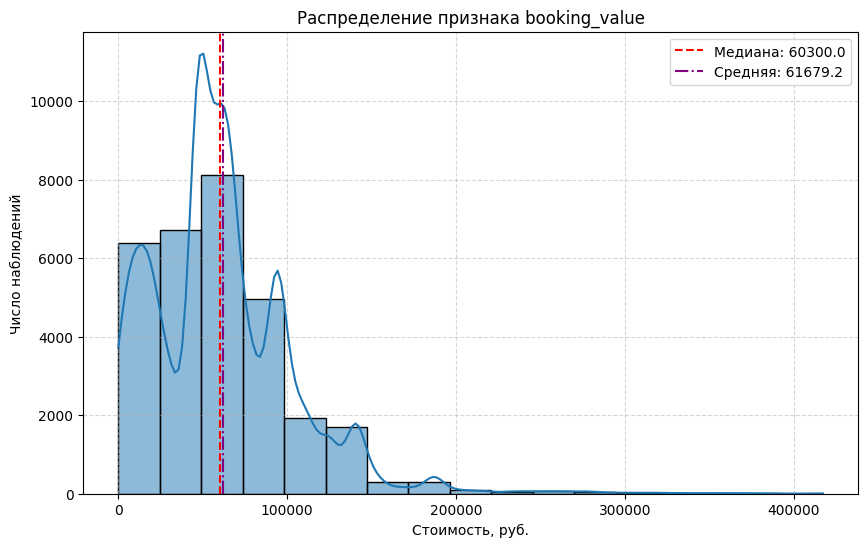

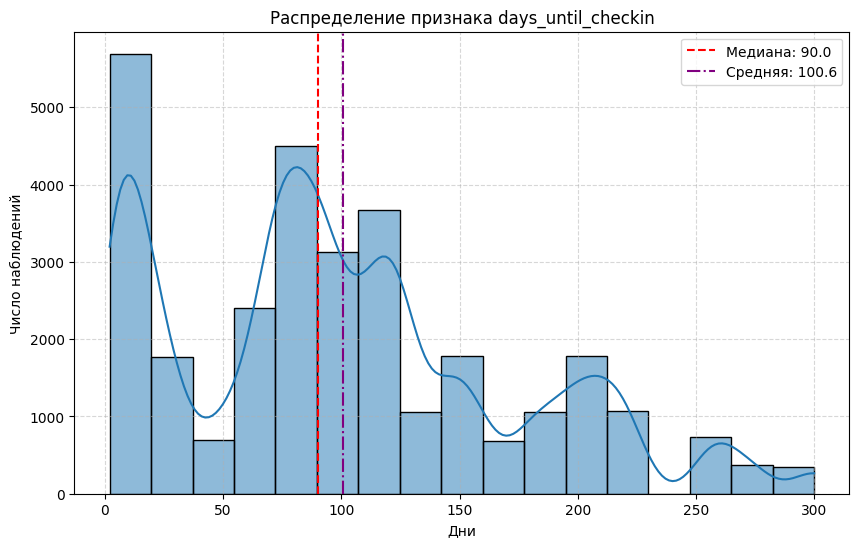

In [23]:
x_labels = {'booking_value': 'Стоимость, руб.', 'days_until_checkin': 'Дни'}

for col in numerical_features_hb:
    histogram_chart(df=df_hotel_bookings, attr=col, bins=17, title_text=f'Распределение признака {col}', xlabel=x_labels[col])

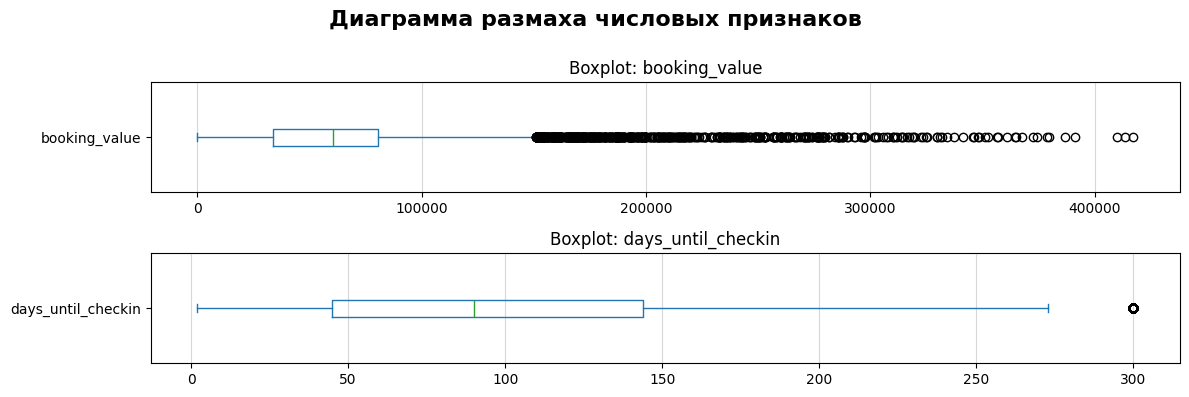

In [24]:
boxplot_chart(df=df_hotel_bookings, feature_list=numerical_features_hb, diagram_name='Диаграмма размаха числовых признаков')

#### Анализ числовых признаков: booking_value и days_until_checkin

**booking_value (стоимость бронирования)**  
Распределение признака сильно смещено вправо: медиана (60 300 руб.) практически совпадает со средним (61 679 руб.), однако длинный правый хвост и экстремальные значения (максимум — 417 221 руб.) указывают на выраженную асимметрию. На boxplot заметно множество выбросов в правой части — это могут быть премиальные бронирования либо аномальные транзакции. Такое поведение признака способно искажать работу моделей, чувствительных к масштабу (линейные модели, kNN), а также влиять на интерпретацию SHAP‑значений. Для снижения влияния хвоста можно применить логарифмическое преобразование — оно уменьшит разброс и приблизит распределение к нормальному.

**days_until_checkin (дни до заезда)**  
Распределение также имеет правостороннюю асимметрию, но менее выраженную: медиана (90 дней) и среднее (100,6 дней) близки, максимум ограничен 300 днями. На графике присутствует один изолированный выброс в районе 300 дней — вероятно, сверхраннее бронирование. В целом признак менее подвержен искажениям по сравнению с `booking_value`, но его длинный хвост всё же может влиять на масштабирование. Логарифмирование здесь необязательно, но допустимо.

**Выводы и рекомендации**  
- `booking_value`: обязательно логарифмировать перед подачей в модели, которые чувствительны к масштабу; при использовании ансамблевых моделей (CatBoost, LightGBM) преобразование не обязательно.  
- `days_until_checkin`: преобразование опционально; достаточно контролировать влияние выброса на масштабирование.   
- Наличие выбросов важно учитывать при выборе метрик качества и валидации: в отдельных сегментах (например, премиальные бронирования) поведение модели может существенно отличаться.

---


#### 1.2.3 Порядковые признаки

In [25]:
df_hotel_bookings[ordinal_features_hb].describe()

,adult_count,child_count,previous_cancellations,previous_no_shows,weekday_nights,weekend_nights,customer_special_requests
count,30733.000000,30733.000000,30733.000000,30733.00000,30733.000000,30733.000000,30733.000000
mean,14.082387,0.356685,0.357303,0.83900,6.536687,1.954772,0.620603
std,48.832586,0.584576,0.629688,0.93191,3.336198,1.476409,0.784428
min,1.000000,0.000000,0.000000,0.00000,1.000000,0.000000,0.000000
25%,1.000000,0.000000,0.000000,0.00000,5.000000,0.000000,0.000000
50%,2.000000,0.000000,0.000000,1.00000,6.000000,2.000000,0.000000
75%,3.000000,1.000000,1.000000,1.00000,9.000000,2.000000,1.000000
max,300.000000,2.000000,5.000000,5.00000,15.000000,6.000000,5.000000


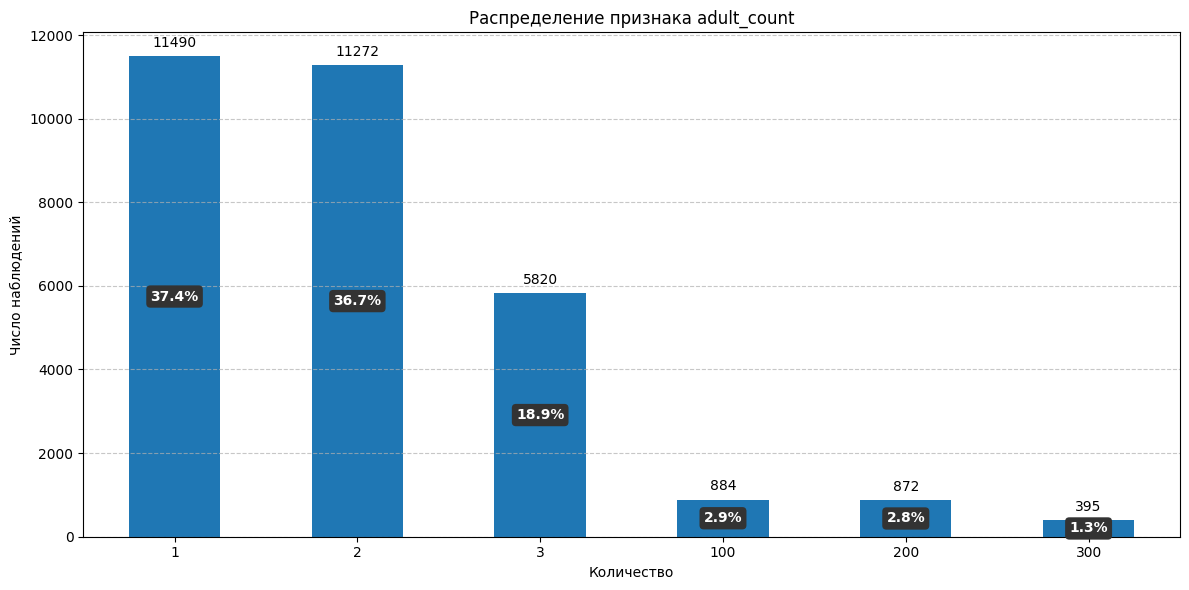

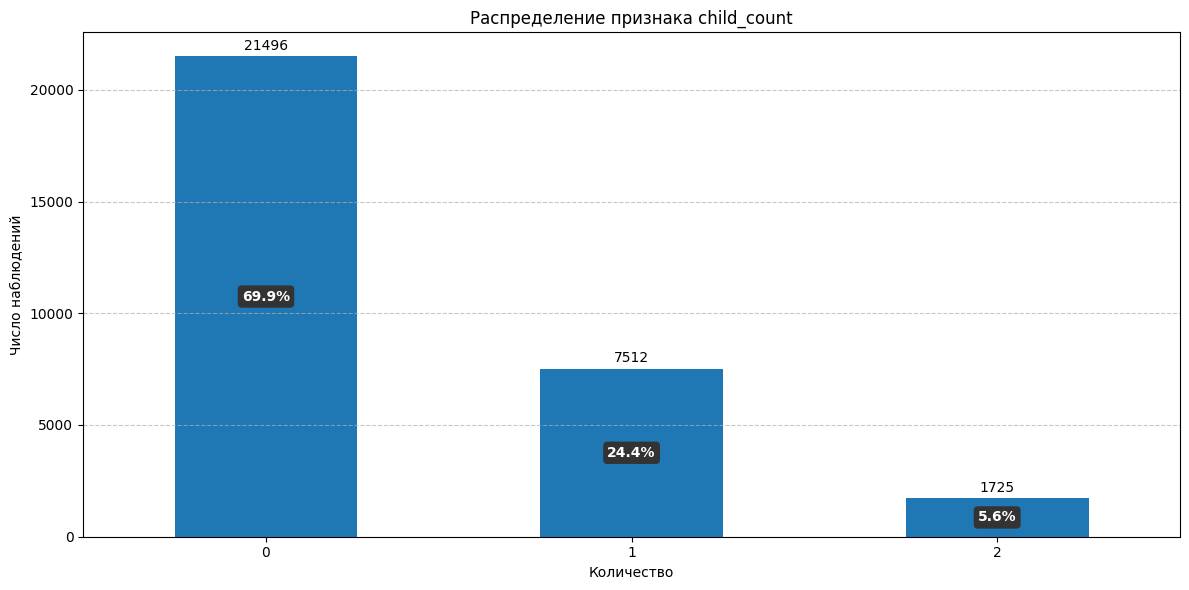

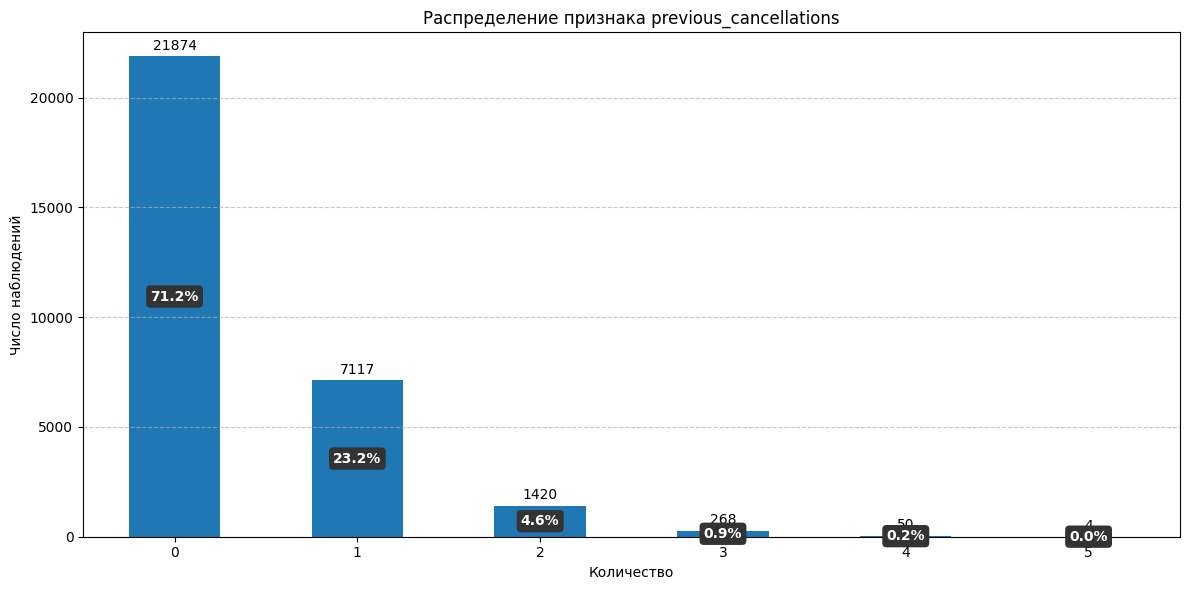

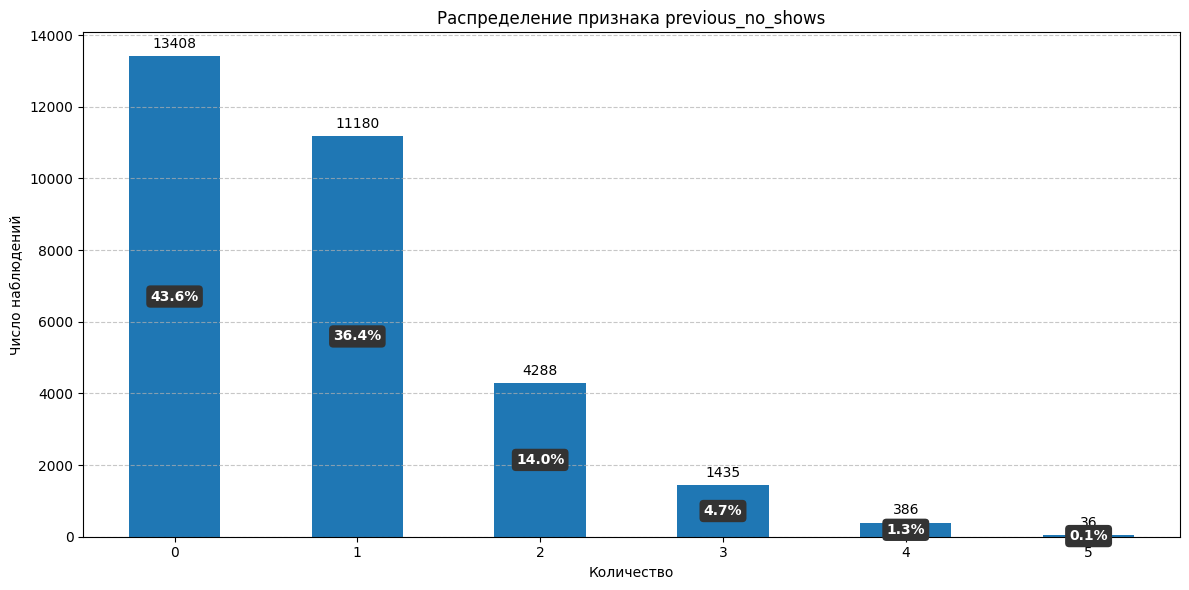

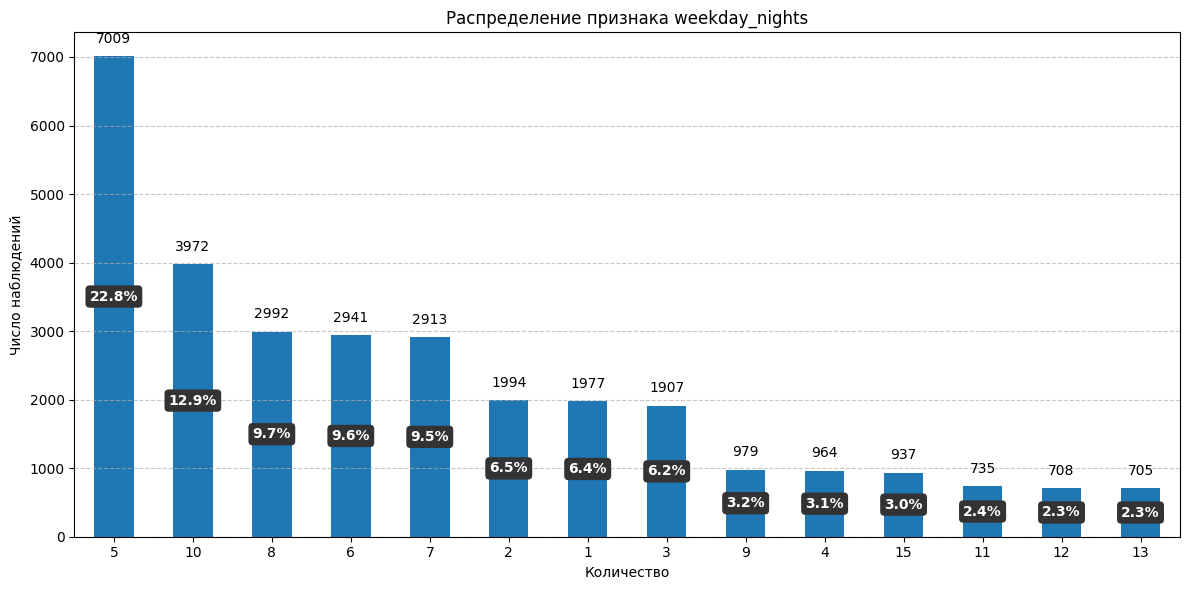

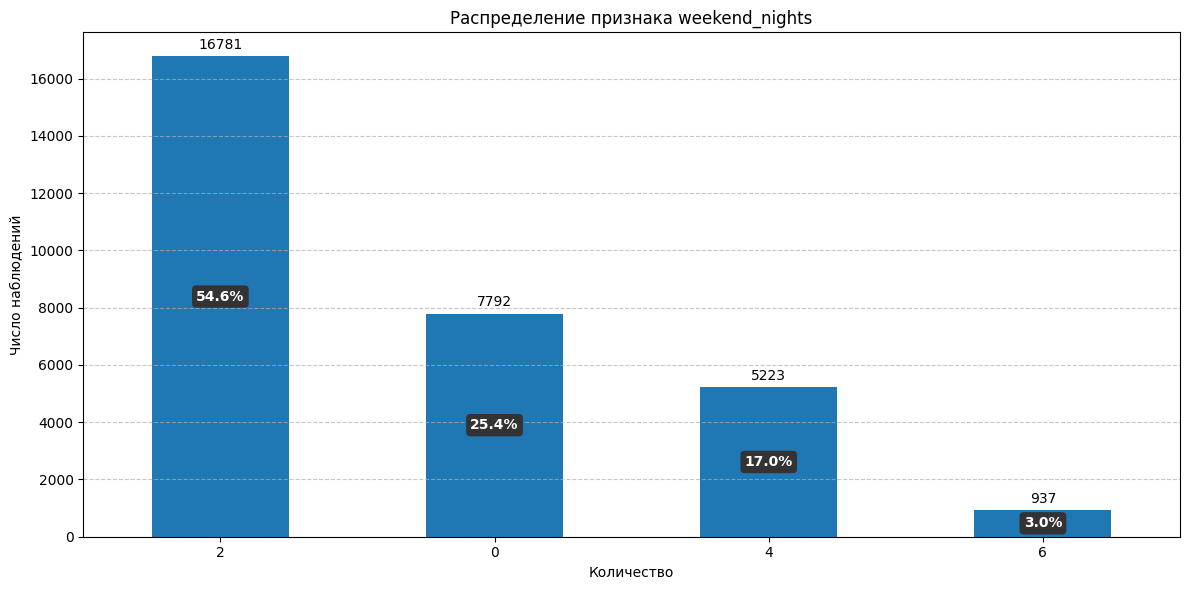

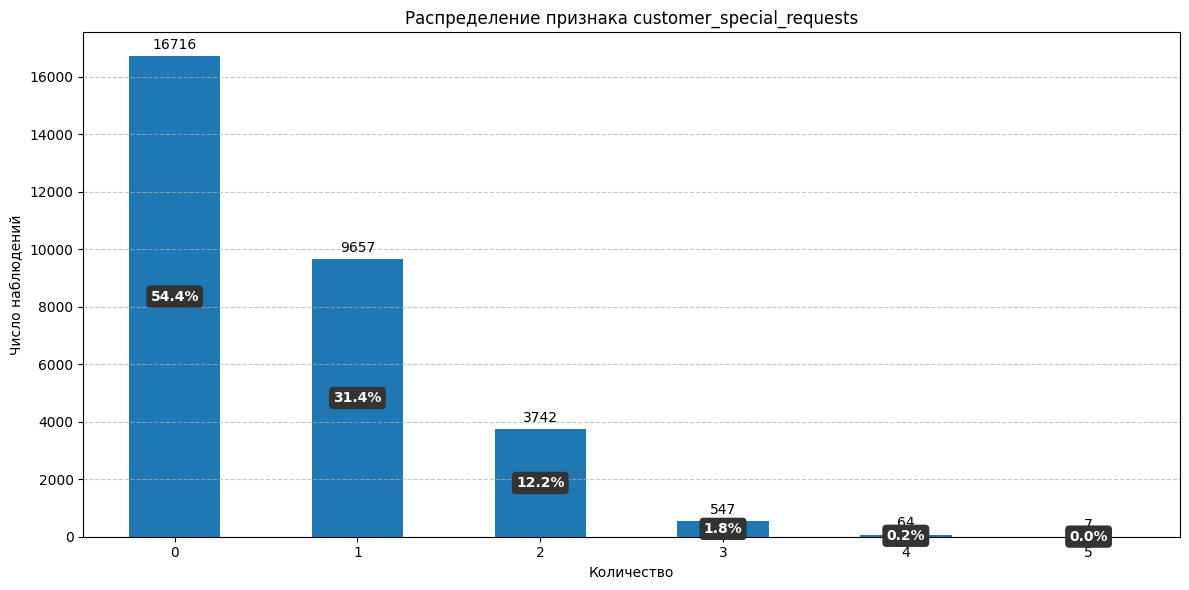

In [26]:
for col in ordinal_features_hb:
    plot_bar_chart(df_hotel_bookings[col], xlabel='Количество', title=f'Распределение признака {col}', top_n=15)

In [27]:
df_hotel_reviews['stay_rating'].describe()

count    25047.000000
mean         3.394339
std          0.541355
min          2.000000
25%          3.000000
50%          3.000000
75%          4.000000
max          5.000000
Name: stay_rating, dtype: float64

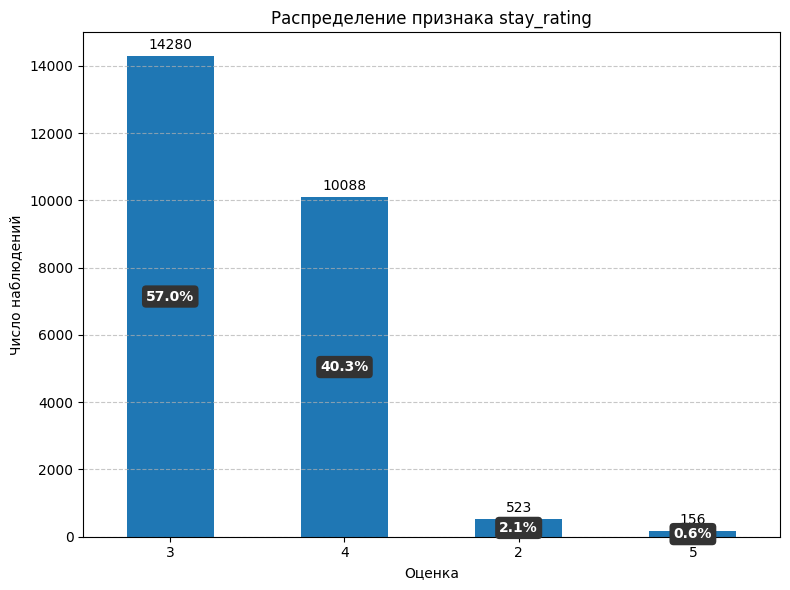

In [28]:
plot_bar_chart(data=df_hotel_reviews['stay_rating'], xlabel='Оценка', title='Распределение признака stay_rating', figsize=(8,6))

In [39]:
df_hotel_bookings.head()

,booking_id,booking_date,sales_channel,adult_count,child_count,returning_customer,previous_cancellations,previous_no_shows,booking_status,booking_value,days_until_checkin,weekday_nights,weekend_nights,meal_plan,parking_included,room_type,customer_special_requests
0,INN00000,2020-07-08,корпоративное_бронирование,300,0,0,0,0,0,6700.0,21,1,0,тип_питания_2,0,тип_1,0
1,INN00001,2021-09-19,корпоративное_бронирование,3,0,1,0,1,0,62300.0,15,5,2,тип_питания_2,0,тип_1,1
2,INN00002,2022-11-19,корпоративное_бронирование,3,0,1,0,2,0,46900.0,96,5,2,тип_питания_1,0,тип_1,0
3,INN00003,2017-02-11,онлайн_бронирование,2,0,0,0,0,0,53600.0,150,6,2,тип_питания_1,0,тип_1,0
4,INN00004,2019-03-06,корпоративное_бронирование,1,0,1,1,1,0,46900.0,96,5,2,тип_питания_1,0,тип_1,1


#### Анализ порядковых признаков

**adult_count (количество взрослых)**  
В данных присутствуют аномальные значения 100, 200 и 300 — это, скорее всего ошибки ввода, которые будут исправлены: 100 → 1, 200 → 2, 300 → 3. В номер физически не может заселиться такое большое число посетителей. Вместе значения 1 и 100, 2 и 200, 3 и 300 дают следующий результат.

| Значение | Количество | Доля |
|----------|-----------|------|
| 1 | 12 374 | 40,3 % |
| 2 | 12 144 | 39,5 % |
| 3 | 6 215 | 20,2 % |


**child_count (количество детей)**  
В 70 % случаев детей нет, в 24 % — один ребёнок, в 6 % — двое. Среднее (0,36), медиана (0).

**previous_cancellations (предыдущие отмены)**  
71 % клиентов не имели отмен, 23 % — одну, 6 % — две и более. Среднее (0,36), медиана (0). Значения 3–5 встречаются крайне редко (менее 1 %).

**previous_no_shows (предыдущие неявки)**  
44 % — без неявок, 36 % — одна, 14 % — две, 6 % — три и более. Среднее (0,84), медиана (1). Признак информативен для прогноза отмен.

**weekday_nights (ночи в будни)**  
Топ 5 значений 5, 10, 8, 6 и 7 ночей. Среднее (6,54), медиана (6) — близки. Диапазон 1–15, без выраженных выбросов.

**weekend_nights (ночи в выходные)**  
Распределение: 2 ночи (55 %), 0 ночей (25 %), 4 ночи (17 %). Среднее (1,95), медиана (2) — близки. Максимум — 6 ночей.

**customer_special_requests (специальные запросы)**  
54 % — без запросов, 31 % — один, 12 % — два, 3 % — три и более. Среднее (0,62), медиана (0). Значения 4–5 крайне редки (менее 0,3 %).

**stay_rating (оценка проживания из отзывов)**  
Шкала 2–5 баллов. 57 % — оценка 3, 40 % — оценка 4, 2 % — оценка 2, 0,6 % — оценка 5. Среднее (3,39), медиана (3). Низкая вариативность (std = 0,54).

**Выводы и рекомендации**  
- `adult_count`: значения 100, 200 и 300 — это ошибки, которые требуют корректировки до реалистичных (1–3).  
- Остальные признаки можно подавать в модели в исходном виде.

---


#### 1.2.4 Категориальные и бинарные признаки

In [29]:
df_hotel_bookings[categorical_features_hb].describe()

,sales_channel,meal_plan,room_type
count,30733,30733,30733
unique,3,5,7
top,офлайн_бронирование,тип_питания_1,тип_1
freq,10447,23604,23687


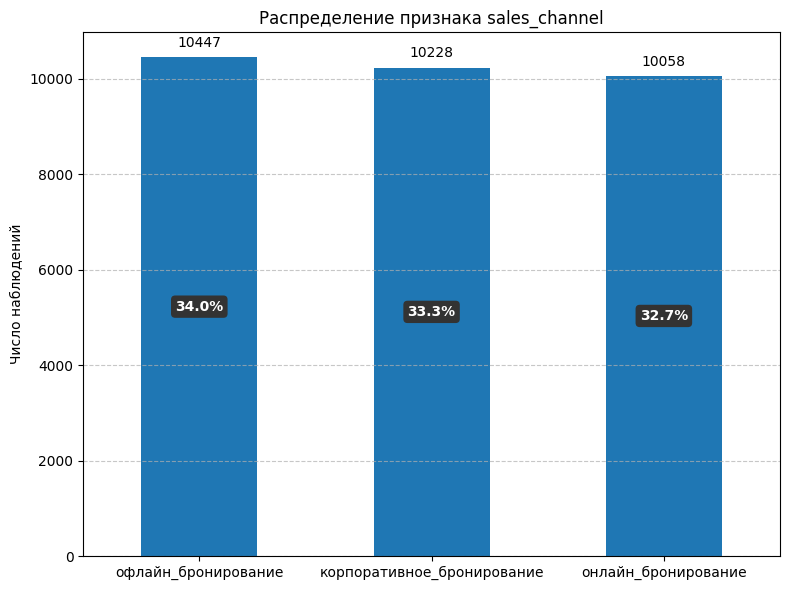

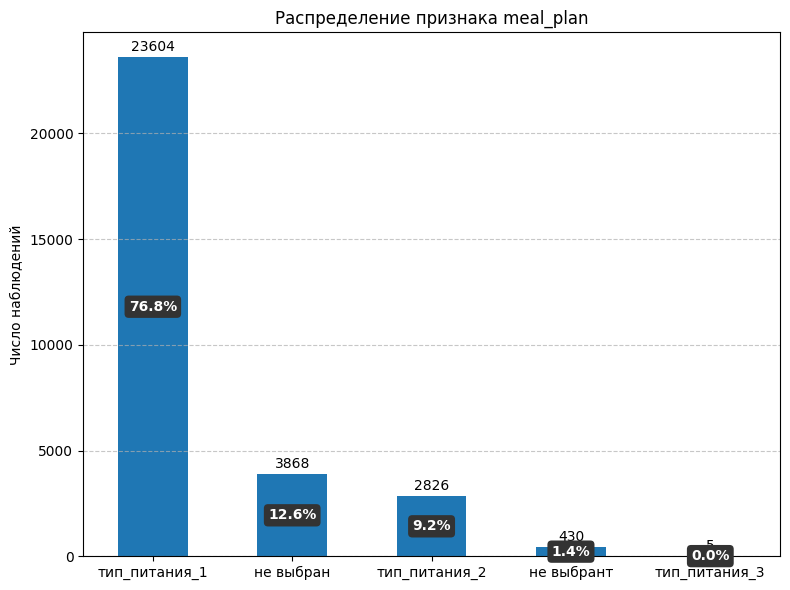

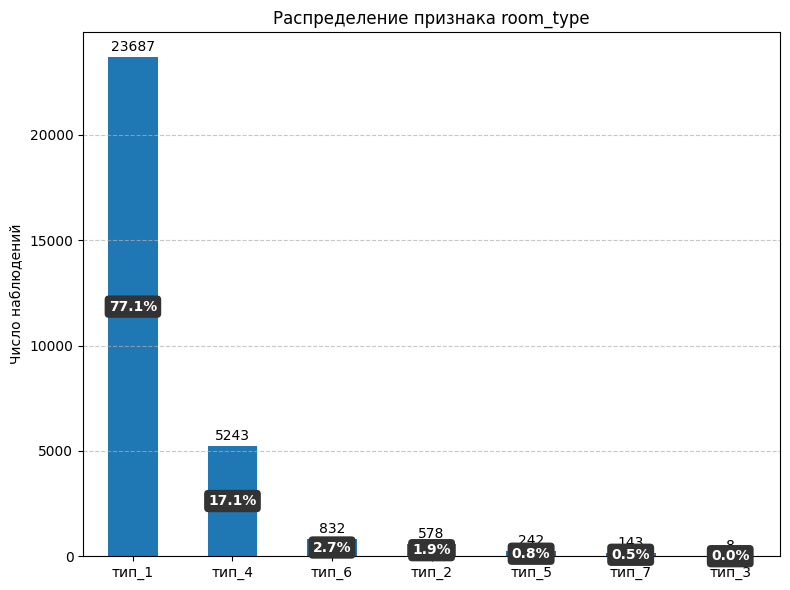

In [30]:
for col in categorical_features_hb:
    plot_bar_chart(df_hotel_bookings[col], xlabel='', title=f'Распределение признака {col}', top_n=10, figsize=(8,6))

In [31]:
df_hotel_bookings[binary_features_hb].describe()

,returning_customer,parking_included
count,30733.000000,30733.000000
mean,0.563726,0.032701
std,0.495930,0.177856
min,0.000000,0.000000
25%,0.000000,0.000000
50%,1.000000,0.000000
75%,1.000000,0.000000
max,1.000000,1.000000


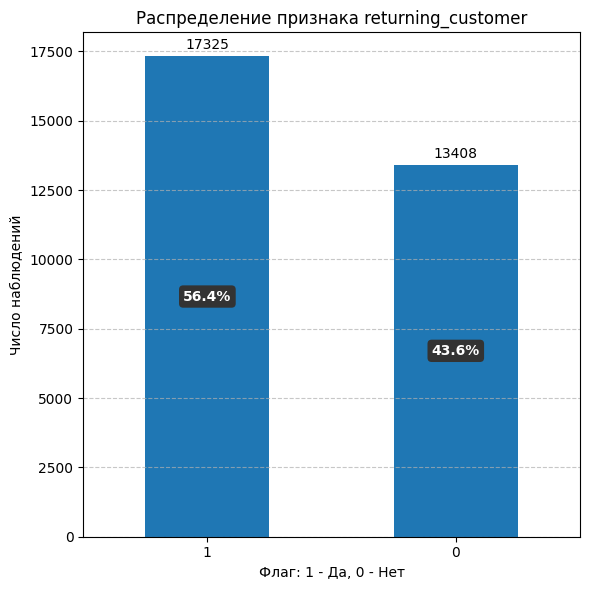

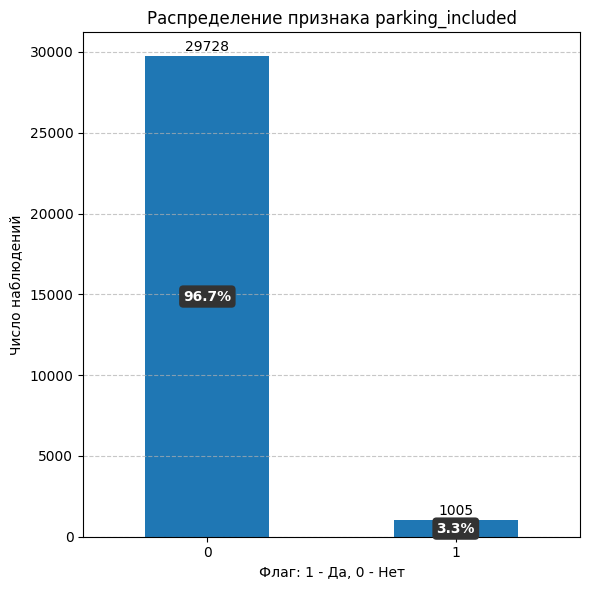

In [32]:
for col in binary_features_hb:
    plot_bar_chart(df_hotel_bookings[col], xlabel='Флаг: 1 - Да, 0 - Нет', title=f'Распределение признака {col}', top_n=10, figsize=(6,6))

#### Анализ категориальных и бинарных признаков

**sales_channel (канал продаж)**  
Три категории, распределены почти равномерно: офлайн — 34,0 % (10 447), корпоративное — 33,3 % (10 228), онлайн — 32,7 % (10 058). Дисбаланса нет, признак информативен.

**meal_plan (тип питания)**  
Доминирует `тип_питания_1` — 76,8 % (23 604). Далее: `не выбран` — 12,6 % (3 868), `тип_питания_2` — 9,2 % (2 826), `тип_питания_3` — 0,02 % (5). Обнаружена опечатка `не выбрант` — 1,4 % (430), требует исправления на `не выбран`. После исправления `тип_питания_3` останется крайне редкой категорией (5 строк) — кандидат на объединение или удаление.

**room_type (тип номера)**  
`тип_1` доминирует — 77,1 % (23 687), `тип_4` — 17,1 % (5 243). Остальные типы суммарно менее 6 %: `тип_6` — 2,7 %, `тип_2` — 1,9 %, `тип_5` — 0,8 %, `тип_7` — 0,5 %, `тип_3` — 0,03 % (8 строк). Редкие категории (`тип_3`, `тип_5`, `тип_7`) стоит объединить в «прочие».

**returning_customer (постоянный клиент)**  
1 — 56,4 % (17 325), 0 — 43,6 % (13 408). Распределение сбалансированное, признак информативен.

**parking_included (включена парковка)**  
0 — 96,7 % (29 728), 1 — 3,3 % (1 005). Сильный дисбаланс, но для бинарного признака допустим. Парковка — редкая опция, может быть информативна как сигнал премиального бронирования.

**Выводы и рекомендации**  
- `meal_plan`: исправить опечатку `не выбрант` → `не выбран`; категорию `тип_питания_3` (5 строк) объединить с `тип_питания_2`.  
- `room_type`: редкие типы (`тип_3`, `тип_5`, `тип_7`) объединить в «прочие».  
- `sales_channel` и `returning_customer` — без замечаний, использовать как есть.  
- `parking_included` — сильный дисбаланс, но оставляем; модель сама определит значимость.

---


#### 1.2.5 Анализ целевой переменной

In [33]:
df_hotel_bookings[target].describe()

count    30733.000000
mean         0.287964
std          0.452822
min          0.000000
25%          0.000000
50%          0.000000
75%          1.000000
max          1.000000
Name: booking_status, dtype: float64

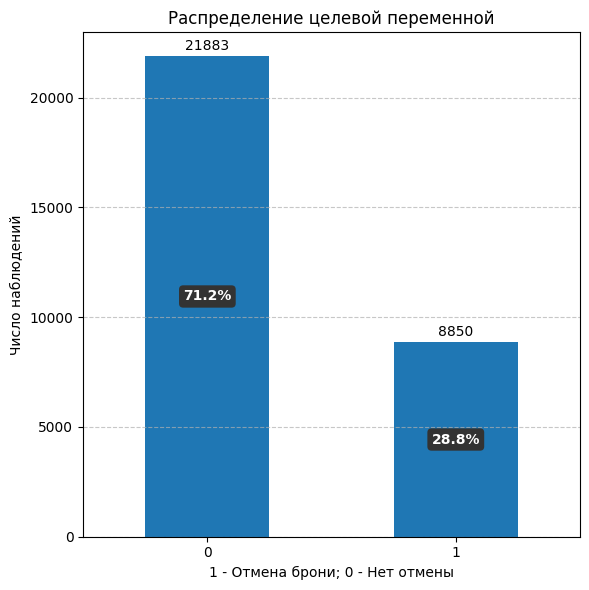

In [34]:
plot_bar_chart(data=df_hotel_bookings[target], xlabel='1 - Отмена брони; 0 - Нет отмены', title='Распределение целевой переменной', figsize=(6,6))

#### Анализ целевой переменной (booking_status)

**Распределение по категориям**  
- 0 (нет отмены): 21 883 наблюдения (71,2 %)  
- 1 (отмена брони): 8 850 наблюдений (28,8 %)  

**Выводы и рекомендации**  
- Дисбаланс классов умеренный (соотношение ~2,5:1), не критичен для большинства ML‑алгоритмов.  
- Допустимо использовать стандартные метрики (Accuracy, F1, Recall, Precision) и техники балансировки (class_weight, SMOTE) при необходимости.  
- Целевая переменная пригодна для моделирования без предварительной трансформации.

---


#### 1.2.6 Исправления по итогам анализа признаков

In [44]:
# 1) adult_count — замена аномальных значений
replace_map = {100: 1, 200: 2, 300: 3}
df_hotel_bookings['adult_count'] = df_hotel_bookings['adult_count'].replace(replace_map)

# 2) meal_plan — исправление опечатки и объединение категорий
df_hotel_bookings['meal_plan'] = df_hotel_bookings['meal_plan'].replace({
    'не выбрант': 'не выбран',
    'тип_питания_3': 'тип_питания_2',
})

# 3) room_type — объединение редких типов в «прочие»
rare_types = ['тип_3', 'тип_5', 'тип_7']
df_hotel_bookings['room_type'] = df_hotel_bookings['room_type'].replace(rare_types, 'прочие')


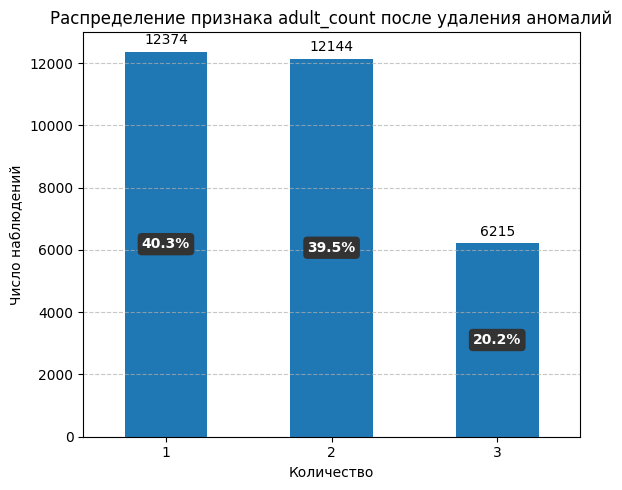

In [47]:
plot_bar_chart(df_hotel_bookings['adult_count'], xlabel='Количество', title=f'Распределение признака adult_count после удаления аномалий', figsize=(6,5))

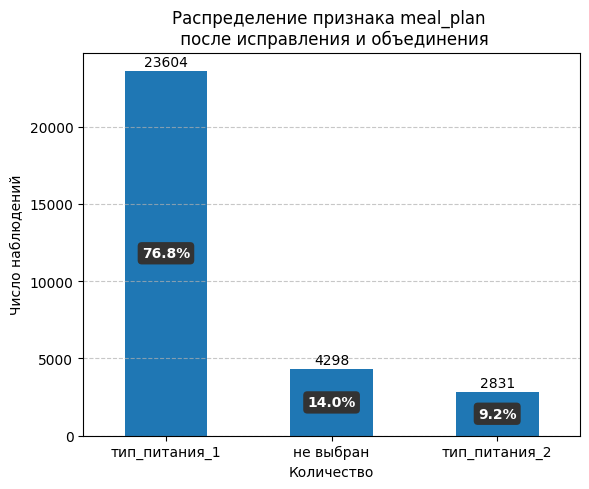

In [50]:
plot_bar_chart(df_hotel_bookings['meal_plan'], xlabel='Количество', title=f'Распределение признака meal_plan \n после исправления и объединения', figsize=(6,5))

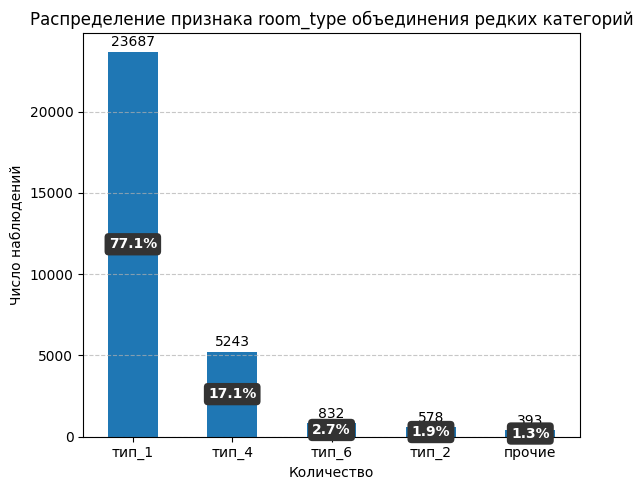

In [51]:
plot_bar_chart(df_hotel_bookings['room_type'], xlabel='Количество', title=f'Распределение признака room_type объединения редких категорий', figsize=(6,5))

#### Комментарий: выполнены корректировки данных в df_hotel_bookings

- Исправлены аномальные значения в `adult_count`: 100 → 1, 200 → 2, 300 → 3 — это устраняет искажения в подсчёте числа гостей.  
- В `meal_plan` устранена опечатка (`не выбрант` → `не выбран`) и объединены редкие категории (`тип_питания_3` → `тип_питания_2`), что снижает шум и улучшает баланс классов.  
- Редкие типы номеров (`тип_3`, `тип_5`, `тип_7`) в `room_type` объединены в категорию «прочие» — это упрощает последующую кодировку признаков и снижает разреженность.  

Данные приведены к консистентному виду, этап очистки завершён.

---


### 1.3 Объединение таблиц

- Соедините таблицу отзывов с таблицей бронирований. Руководствуйтесь правилом: для каждой даты бронирования в столбце `booking_date` нужно взять комментарий и оценку клиента по предыдущей ближайшей дате отзывов, указанной в столбце `review_date`. Это позволит связать обратную связь клиента с конкретным периодом проживания, что критически важно для анализа удовлетворённости гостей.

- Сделайте выводы о том, как прошло объединение и что получилось в результате.

### Создание новых признаков

- Создайте не менее трёх признаков на основе данных о брони.

- Создайте новые признаки на основе текстов отзывов, используя один из методов векторизации. Решение о количестве таких признаков примите самостоятельно.

- Сделать выводы о созданных признаках.

### Анализ итоговой таблицы

- Проанализируйте итоговую таблицу.

- Сделайте выводы о данных для моделирования.

## Этап 2: моделирование

### Обучение и оптимизация модели

- Выберите и обучите не менее двух моделей из списка:

  - Random Forest;

  - CatBoost;

  - LightGBM;

  - XGBoost;

  - любую другую на ваш выбор.

- Разделите данные на три выборки:
  - Обучающую — для обучения моделей (60% данных);
  - Калибровочную — для проведения калибровки модели (20% данных);
  - Тестовую — для финальной оценки качества выбранной модели (20% данных).

- Проведите кросс-валидацию, используйте три фолда. Размер выборки для валидации — 2000.

- Оптимизируйте гиперпараметры с помощью Optuna. Количество гиперпараметров — не менее трёх. Ключевая метрика для оптимизации — Incremental Revenue.

- Сделайте выводы о том, какая модель показала лучшие результаты.

### Калибровка модели и пересчёт результатов

- Выбрав модель, откалибруйте её на полной тренировочной выборке, чтобы повысить обобщающую способность и адаптировать предсказания под бизнес-задачи.

- Сделайте о результатах калибровки модели.

### Поиск порога классификации

- Используя откалиброванную модель и калибровочную выборку, найдите порог классификации, при котором достигается максимальный Incremental Revenue.

- Сделайте выводы о пороге классификации.

### Анализ матрицы классификаций

Оцените стабильность модели на тестовых данных.
- Постройте:
    - матрицу ошибок на калибровочных данных;
    - матрицу ошибок на тестовых данных.

- Посчитайте IR на калибровочных и на тестовых данных.

- Сделайте вывод о стабильности модели.

### Фиксирование итоговой модели

- Зафиксисруйте лучшую модель и найденный порог.


### Анализ важности признаков

- Оцените важность признаков с помощью любого подходящего инструмента:
  - feature_importances;
  - SHAP;
  - встроенной в модель собственной функции оценки важности.

- Сделайте выводы о влиянии признаков на целевую переменную.

## Этап 3: расчёт экономической эффективности модели

Оцените, насколько выгодно внедрять выбранную модель в работу отеля. Для этого нужно выяснить, какой экономический эффект даёт модель и укладываются ли ключевые метрики в заданный уровень.

Если расчёты покажут, что какой-либо показатель не достигает необходимого уровня, то это сигнал к доработке модели. Возможно, вам нужно пересмотреть порог классификации, добавить новые признаки, поменять модель, по-другому предобработать исходные данные — экспериментируйте!

- Шаг 1: подготовка данных. Подготовьте данные для расчётов. Данные для показателей до внедрения модели рассчитывайте с использованием тестовых данных `y_test`, данные после внедрения получите с помощью предсказаний модели `y_pred`.

- Шаг 2: расчёт показателей до и после внедрения модели. Вычислите:
  - Долю отмен бронирования до и после внедрения модели;
  - Загрузку отеля до и после внедрения модели;
  - IR.

- Шаг 3: расчёт динамики показателей. Вычислите:
  - Динамику доли отмен бронирования;
  - Динамику загрузки отеля;
  - Относительный IR — на сколько процентов `IR_после` выше, чем `IR_до`.


Ваша модель должна достигнуть следующих результатов:

- Доля отмен после внедрения модели — 10%

- Загрузка отеля не должна уменьшиться больше чем на 8% после внедрения модели.

- Относительный IR должен составить не менее 50%.

Сделайте выводы о том, получилось ли достичь целевых показателей для бизнеса.


## Этап 4: выводы по проекту

Выводы должны состоять из двух логически связанных разделов:

- «Проделанная работа» — описание этапов и решений;

- «Бизнес‑выводы» — интерпретация результатов и рекомендации.

В каждом разделе опишите результаты без избыточной детализации, с опорой на факты и цифры.

### Выводы о проделанной работе

В этом разделе опишите основные этапы проделанной работы по построению модели. Опишите, как проходили следующие шаги:
- Подготовка данных;
- Моделирование;
- Оценка метрик;
- Анализа важности факторов.

### Выводы по анализу эффективности модели

В этом разделе ответьте на вопрос: «Что это значит для бизнеса?» Для этого интерпретируйте результаты вашей работы, дайте им экономическую оценку, а заказчику — рекомендации.

Включите следующие пункты:

- Итоговая оценка достижения цели:
  - Вспомните цель проекта и определите, достигнута ли она. Аргументируйте свой ответ.

- Результаты по ключевым метрикам. Для каждого показателя приведите:
  - Значение до внедрения модели.
  - Значение после внедрения.
  - Изменение в процентах с расчётом по формуле.
  
- Сообщите заказчику, достигнуты ли целевые показатели по метрикам.

- Анализ важности признаков:
  - Опишите для заказчиков основные 10 признаков, влияющих на резкие отмены заказов.
  - Кратко объясните, как они влияют на целевую переменную. Пример такого объяснения: «лояльность клиента снижает риск отмены на 15%».

- Рекомендации для бизнеса:
  - Предложите 2–3 конкретных шага по оптимизации работы сети отелей.